In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#Data Loading & Checking
df = pd.read_csv(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML regression project medical cost prediction\medical_insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.shape

(2772, 7)

In [ ]:
#Data Cleaning
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1435)

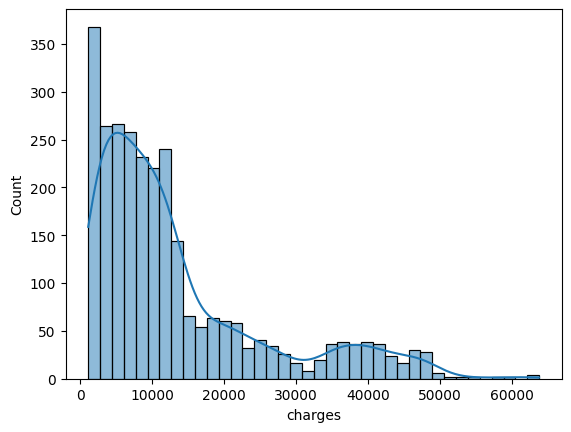

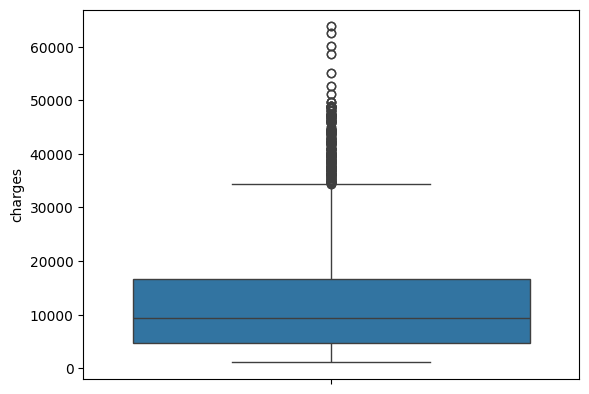

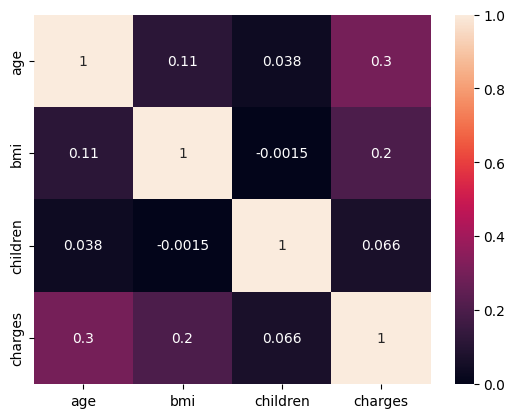

In [ ]:
#EDA Data Visualization
sns.histplot(df["charges"], kde=True)
plt.show()

sns.boxplot(df["charges"])
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [21]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

In [23]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [26]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Support Vector Regression": SVR(),

    "KNN": KNeighborsRegressor()

}

In [27]:
best_model = None
best_score = -1

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, prediction)

    print("="*50)
    print(name)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R2 Score :", r2)

    if r2 > best_score:
        best_score = r2
        best_model = model

Linear Regression
MAE : 4167.301435974504
MSE : 39922479.35435014
RMSE : 6318.423803002624
R2 Score : 0.7398864322395977
Decision Tree
MAE : 707.8277094594595
MSE : 11047143.258592527
RMSE : 3323.724305442996
R2 Score : 0.9280227106876902
Random Forest
MAE : 1304.9597424869191
MSE : 7560924.456026276
RMSE : 2749.7135225376255
R2 Score : 0.9507370517154623
Support Vector Regression
MAE : 8297.131810896306
MSE : 163569917.51454753
RMSE : 12789.44555149079
R2 Score : -0.06573428081308741
KNN
MAE : 2696.547851476036
MSE : 24241300.82891373
RMSE : 4923.545554670306
R2 Score : 0.8420566220400619


In [28]:
import pickle

# Train the best model
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

best_model.fit(X_train, y_train)

# Save the trained model
with open("best_model.pkl", "wb") as model_file:
    pickle.dump(best_model, model_file)

# Save the fitted scaler
with open("scaler.pkl", "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [30]:
import pickle
import numpy as np

# Load the trained model
with open(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML regression project medical cost prediction\best_model.pkl", "rb") as model_file:
    model = pickle.load(model_file)

# Load the scaler
with open(r"C:\Users\inter\Desktop\Shrutika\Python-Practical\ML regression project medical cost prediction\scaler.pkl", "rb") as scaler_file:
    scaler = pickle.load(scaler_file)


def predict_insurance(age,
                      sex,
                      bmi,
                      children,
                      smoker,
                      region):
    """
    Predict Medical Insurance Charges

    Encoding:
    sex     : female=0, male=1
    smoker  : no=0, yes=1
    region  :
        northeast = 0
        northwest = 1
        southeast = 2
        southwest = 3
        (Use the same encoding as used during training.)
    """

    input_data = np.array([[age,
                            sex,
                            bmi,
                            children,
                            smoker,
                            region]])

    # Scale the input
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = model.predict(input_scaled)

    return prediction[0]